# Laboratorio: resolución numérica de EDOs — guía del docente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/docente/lab-EDO-numerico.ipynb)

> Versión con las soluciones completas. La versión para estudiantes, con esqueletos en lugar de las soluciones, es `notebooks/lab-EDO-numerico.ipynb`.

Este es el primer laboratorio de la materia y es distinto de los que siguen: acá no modelamos nada nuevo, sino que aprendemos a **resolver numéricamente** las ecuaciones diferenciales que el resto del curso plantea. Las notas no tratan estos temas, así que el texto de este notebook es la única presentación que van a tener: léanlo con cuidado, no solo las consignas.

**Qué vamos a hacer.** Implementar desde cero el método de Euler, medir su orden de convergencia, descubrir que puede ser *inestable* aunque sea consistente (y qué significa que una ecuación sea *rígida*), implementar Runge–Kutta de orden 2 y 4 y compararlos, aplicar todo esto a sistemas (oscilador, energía) y, finalmente, usar `scipy.integrate.solve_ivp` como se usa en la práctica profesional: tolerancias, salida densa y eventos. Cerramos simulando los modelos SIR y SEIR del texto.

**Herramientas disponibles.** El módulo `imc` del repositorio trae `imc.numerico` con implementaciones de referencia (`euler`, `rk2`, `rk4`, todas con la firma `metodo(f, t0, y0, h, n, args=())` y campos `f(t, y, *args)` como en `solve_ivp`). Las vamos a usar para *verificar* lo que ustedes escriban, no en lugar de escribirlo. `imc.fases` (retratos de fase) y `imc.estilo` (colores, figuras) también están a mano.

**Cómo se evalúa.** El laboratorio es requisito de aprobación: lo que se evalúa es la sección final de **interpretación escrita**, no el código. Cada tarea dice qué se espera y trae una celda de verificación que les avisa si van bien. Tiempo estimado: una sesión larga (4 h) o dos sesiones; las Tareas 1–5 son la primera mitad.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from imc import estilo, datos
from imc.estilo import COLORES
from scipy.integrate import solve_ivp
from imc import numerico
from imc.estilo import CICLO
import time
estilo.activar()

## 1. Por qué resolver numéricamente, y cómo: la idea de discretizar

Casi ninguna de las ecuaciones del curso tiene solución en fórmula cerrada. La logística sí; el péndulo, Lotka–Volterra, el SIR, no. Y aun cuando la fórmula existe, lo que queremos en general es *ver* la solución para muchos parámetros y datos iniciales, cosa que solo una computadora hace rápido. Todo lo que sigue es para el **problema de valores iniciales**

$$\dot y(t) = f(t, y(t)),\qquad y(t_0) = y_0,$$

donde $y$ puede ser un número o un vector (un sistema de EDOs es exactamente lo mismo con $y\in\mathbb R^d$).

La computadora no puede representar una función $y(t)$ definida en un continuo de tiempos. Lo que hace es **discretizar**: elige un paso $h>0$, los instantes $t_k = t_0 + k h$ ($k = 0, 1, \dots, n$) y busca números $y_0, y_1, \dots, y_n$ que aproximen $y(t_0), y(t_1), \dots, y(t_n)$. Un *método numérico* es una regla para pasar de $y_k$ a $y_{k+1}$ usando $f$. Las preguntas que organizan este laboratorio son tres:

1. **Consistencia y orden:** cuando $h\to 0$, ¿el error tiende a cero? ¿Qué tan rápido?
2. **Estabilidad:** para un $h$ fijo, ¿los errores que se cometen en cada paso se amortiguan o se amplifican?
3. **Costo:** ¿cuántas evaluaciones de $f$ hacen falta para lograr una precisión dada?

### El método de Euler

Es el método más simple y el que da la intuición para todos los demás. Si $y$ es suave, el desarrollo de Taylor alrededor de $t_k$ dice

$$y(t_{k+1}) = y(t_k) + h\,\dot y(t_k) + \frac{h^2}{2}\,\ddot y(\xi) = y(t_k) + h\,f(t_k, y(t_k)) + O(h^2).$$

Si descartamos el término $O(h^2)$ y reemplazamos $y(t_k)$ por su aproximación $y_k$ queda el **método de Euler (explícito)**:

$$\boxed{\;y_{k+1} = y_k + h\,f(t_k, y_k)\;}$$

Geométricamente: desde el punto $(t_k, y_k)$ avanzamos un tramo de recta con la pendiente que el campo $f$ indica *en ese punto*. Es el "campo de direcciones" del texto seguido a mano.

**Errores.** El término descartado, $\tfrac{h^2}{2}\ddot y(\xi)$, es el **error local** (el que se comete en un solo paso si se parte del valor exacto): es $O(h^2)$. Para llegar de $t_0$ a un tiempo fijo $T$ hacen falta $n = (T-t_0)/h$ pasos, y los errores locales se acumulan: el **error global** $|y_n - y(T)|$ es, a lo sumo, del orden de $n\cdot h^2 = (T-t_0)\,h$. Es decir, es $O(h)$: se dice que Euler es un método de **orden 1**. En general, un método tiene orden $p$ si su error global es $O(h^p)$; el error local es entonces $O(h^{p+1})$.

**Cómo se mide el orden en la práctica.** Si el error global se comporta como $e(h)\approx C h^p$, entonces $\log e = \log C + p\log h$: en un gráfico log-log del error contra $h$, los puntos caen sobre una recta de pendiente $p$. Para hacerlo hace falta conocer la solución exacta (o una aproximación muchísimo mejor); por eso el orden se mide con ecuaciones de juguete y se confía en que se mantiene en las demás. Esto es lo que van a hacer en la Tarea 2.

**Errores típicos** al implementar Euler: evaluar $f$ en $t_{k+1}$ en lugar de $t_k$; usar `range(n+1)` y salirse del array; olvidar que $y_k$ puede ser un vector (conviene trabajar siempre con `np.ndarray` de forma `(dim,)`, incluso en dimensión 1); y elegir $n$ como `T/h` sin redondear, con lo que $t_n$ no es $T$.

### Tarea 1: Euler desde cero

Implementá `euler_mio(f, t0, y0, h, n, args=())` con la misma firma que `imc.numerico.euler`: devuelve `(t, y)` con `t` el array de los $n+1$ instantes y `y` un array de forma `(n+1, dim)` con las aproximaciones (aunque la ecuación sea escalar, `y[:, 0]` es la solución). El campo se llama como `f(t, y, *args)`.

**Qué se espera.** Que la celda de verificación no proteste (compara tu implementación con la de referencia sobre una ecuación no lineal) y que después mires la figura que sigue: el Ejercicio "lambda" del texto, $\dot y = \lambda y$, $y(0)=1$, resuelto con Euler para $\lambda = 2$, $-1$ y $-10$ y varios pasos $h$. Para $\lambda=2$ y $\lambda=-1$ tiene que verse que las poligonales de Euler se acercan a la exponencial exacta cuando $h$ baja. Para $\lambda=-10$ pasa algo raro con los $h$ grandes; guardá la observación para la Tarea 3.

In [2]:
def euler_mio(f, t0, y0, h, n, args=()):
    """Método de Euler para y' = f(t, y). Devuelve (t, y) con y de forma (n+1, dim)."""
    y0 = np.atleast_1d(np.asarray(y0, dtype=float))
    t = t0 + h * np.arange(n + 1)
    y = np.zeros((n + 1, len(y0)))
    y[0] = y0
    for k in range(n):
        y[k + 1] = y[k] + h * np.asarray(f(t[k], y[k], *args))
    return t, y

In [3]:
# Verificación: comparar con la implementación de referencia sobre un sistema no lineal con parámetros
def prueba(t, X, a):
    x, v = X
    return [v, -a * np.sin(x) - 0.1 * v]

t1, y1 = euler_mio(prueba, 0.0, [1.0, 0.0], 0.05, 200, args=(2.0,))
t2, y2 = numerico.euler(prueba, 0.0, [1.0, 0.0], 0.05, 200, args=(2.0,))
assert y1.shape == (201, 2), f"forma incorrecta: {y1.shape}"
assert np.allclose(t1, t2) and np.allclose(y1, y2), "no coincide con imc.numerico.euler"
print("euler_mio: OK")

euler_mio: OK


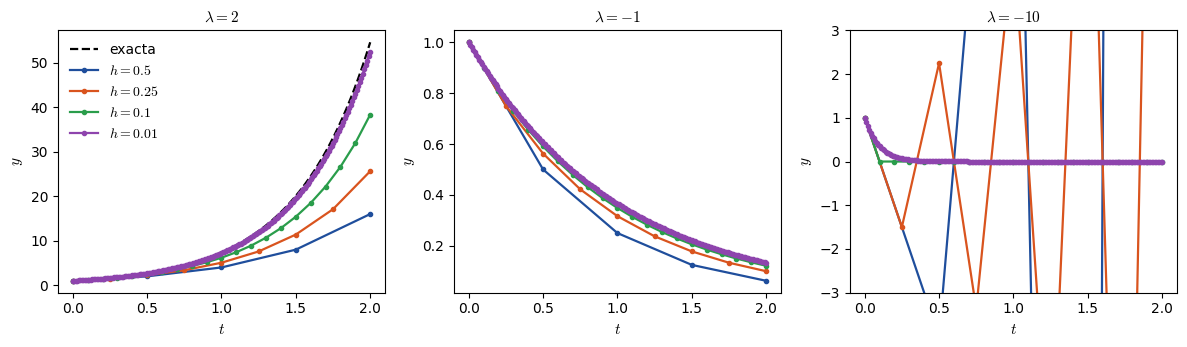

In [4]:
# Ejercicio "lambda": y' = lam*y, y(0) = 1, Euler con distintos h
lams = [2.0, -1.0, -10.0]
hs = [0.5, 0.25, 0.1, 0.01]
T = 2.0
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, lam in zip(axs, lams):
    tt = np.linspace(0, T, 300)
    ax.plot(tt, np.exp(lam * tt), "k--", label="exacta")
    for h, c in zip(hs, CICLO):
        t, y = euler_mio(lambda t, y, lam: lam * y, 0.0, 1.0, h, int(round(T / h)), args=(lam,))
        ax.plot(t, y[:, 0], "o-", ms=3, color=c, label=f"$h = {h}$")
    ax.set_title(rf"$\lambda = {lam:g}$"); ax.set_xlabel("$t$"); ax.set_ylabel("$y$")
    if lam == -10:
        ax.set_ylim(-3, 3)
axs[0].legend()
fig.tight_layout()

### Medir el orden

Para medir el orden necesitamos una ecuación con solución exacta. Usamos la logística del texto,

$$\dot P = rP\Bigl(1-\frac{P}{K}\Bigr),\qquad P(t) = \frac{K}{1 + \frac{K-P_0}{P_0}e^{-rt}},$$

y el protocolo del ejercicio de la logística del texto: resolver en $[0, 5]$ con $h_m = 2^{-m}$, $m = 0, \dots, 8$, guardar el error en el último paso $e_m = |y_n - P(5)|$ y graficar $\log e_m$ contra $\log h_m$. La pendiente de la recta que mejor ajusta esos puntos es el orden empírico. (Saben mínimos cuadrados: `np.polyfit(np.log(hs), np.log(errores), 1)` hace el ajuste lineal.)

Un detalle práctico: para cada $h$, el número de pasos es $n = (T - t_0)/h$, que tiene que ser entero. Con $h = 2^{-m}$ y $T = 5$ lo es; en general usen `int(round((T - t0)/h))`.

### Tarea 2: Orden de convergencia de Euler

Escribí dos funciones:

* `error_final(metodo, f, exacta, t0, T, y0, hs, args=())`: para cada `h` en `hs` resuelve con `metodo` (una función con la firma de `euler_mio`) y devuelve el array de errores $|y_n - y(T)|$, donde `exacta(T)` es la solución exacta (escalar).
* `orden_empirico(hs, errores)`: la pendiente de la recta de mínimos cuadrados de $\log(\text{errores})$ contra $\log(\text{hs})$.

Aplicalas a la logística con $r = 1$, $K = 1$, $P_0 = 0.1$, $T = 5$ y $h_m = 2^{-m}$, $m = 0, \dots, 8$.

**Qué se espera.** Un gráfico log-log (usá `ax.loglog`) del error contra $h$ con los puntos alineados y una pendiente cercana a 1. Es normal que el primer punto o dos ($h$ grande) se aparten de la recta: la estimación $e \approx C h^p$ vale para $h$ chico. Chequeá que el error se reduce a la mitad cada vez que $h$ se reduce a la mitad.

orden empírico de Euler: 1.0669749592334639
cociente de errores consecutivos (debería tender a 2): [2.72 2.23 2.09 2.04 2.02 2.01 2.   2.  ]


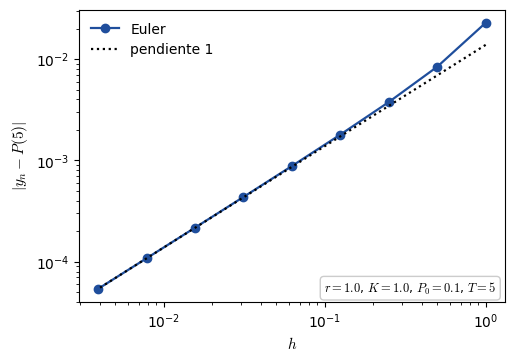

In [5]:
r, K, P0, T = 1.0, 1.0, 0.1, 5.0
logistica = lambda t, P, r, K: r * P * (1 - P / K)
P_exacta = lambda t: K / (1 + (K - P0) / P0 * np.exp(-r * t))

def error_final(metodo, f, exacta, t0, T, y0, hs, args=()):
    """Errores |y_n - exacta(T)| de `metodo` para cada paso h en hs."""
    errores = []
    for h in hs:
        n = int(round((T - t0) / h))
        t, y = metodo(f, t0, y0, h, n, args=args)
        errores.append(abs(y[-1, 0] - exacta(T)))
    return np.array(errores)

def orden_empirico(hs, errores):
    """Pendiente de log(errores) contra log(hs) (ajuste por mínimos cuadrados)."""
    return np.polyfit(np.log(hs), np.log(errores), 1)[0]

hs = 2.0 ** -np.arange(0, 9)
err_euler = error_final(euler_mio, logistica, P_exacta, 0.0, T, P0, hs, args=(r, K))
print("orden empírico de Euler:", orden_empirico(hs, err_euler))
print("cociente de errores consecutivos (debería tender a 2):", np.round(err_euler[:-1] / err_euler[1:], 2))

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.loglog(hs, err_euler, "o-", label="Euler")
ax.loglog(hs, err_euler[-1] * (hs / hs[-1]), "k:", label="pendiente 1")
ax.set_xlabel("$h$"); ax.set_ylabel("$|y_n - P(5)|$"); ax.legend()
estilo.parametros(ax, rf"$r={r}$, $K={K}$, $P_0={P0}$, $T={T:g}$", loc="lower right")

In [6]:
# Verificación
assert len(err_euler) == len(hs) and np.all(np.diff(err_euler) < 0), "el error debería decrecer con h"
p = orden_empirico(hs, err_euler)
assert 0.85 < p < 1.15, f"orden empírico {p:.2f}: se esperaba ~1"
print(f"orden empírico {p:.3f}: OK")

orden empírico 1.067: OK


## 2. Estabilidad: cuando el error no se amortigua

Que un método sea de orden 1 dice qué pasa cuando $h\to 0$. En la práctica $h$ es un número fijo, y la pregunta relevante es otra: con *ese* $h$, ¿los errores se amplifican paso a paso o se atenúan? La ecuación de prueba para pensarlo es la más simple posible,

$$\dot y = \lambda y,\qquad y(0) = 1,\qquad \lambda<0,$$

cuya solución exacta $e^{\lambda t}$ decae a cero. Euler da $y_{k+1} = y_k + h\lambda y_k = (1 + h\lambda)\,y_k$, o sea

$$y_k = (1 + h\lambda)^k .$$

El número $R = 1 + h\lambda$ es el **factor de amplificación**: es lo que el método hace en un paso con la solución (y con cualquier error que arrastre, porque la ecuación es lineal). La solución numérica decae, como debe, solo si

$$|1 + h\lambda| < 1 \iff -2 < h\lambda < 0 \iff h < \frac{2}{|\lambda|}.$$

Si $h > 2/|\lambda|$, el factor es menor que $-1$: la solución numérica cambia de signo en cada paso y crece en módulo, aunque la exacta se muera. Si $2/|\lambda| > h > 1/|\lambda|$ decae pero oscilando, cosa que la solución exacta nunca hace. Fijate que el problema no es de precisión: con $h$ un poco por encima del umbral Euler es *cualitativamente* incorrecto, no "un poco impreciso". Esto es la **estabilidad** (más precisamente, estabilidad absoluta) del método, y depende del producto $h\lambda$, no de $h$ solo.

**Interpretación geométrica.** En cada paso Euler sigue la tangente a la solución exacta que pasa por $(t_k, y_k)$. Cuando $|\lambda|$ es grande, esas soluciones se acercan al equilibrio $y=0$ muy rápido, tanto que la tangente cruza el eje y sale del otro lado, más lejos de lo que empezó. Esa es la figura que pide el ítem 3 del Ejercicio "lambda".

**Rigidez.** Una ecuación (o sistema) es **rígida** (*stiff*) cuando contiene escalas de tiempo muy distintas: una componente que decae rapidísimo (un $\lambda$ negativo enorme) junto con una dinámica lenta que es la que nos interesa. La componente rápida desaparece en un instante y no aporta nada visible a la solución, pero obliga a un método explícito a usar $h < 2/|\lambda|$ *durante toda la simulación*, aunque la solución sea suave y lenta. Es un desperdicio enorme, y en sistemas grandes (reacciones químicas, circuitos, discretizaciones de EDPs como las de la Parte III) es la regla, no la excepción.

**Euler implícito.** La cura es evaluar $f$ en el punto de llegada:

$$y_{k+1} = y_k + h\,f(t_{k+1}, y_{k+1}).$$

Es una ecuación (en general no lineal) para $y_{k+1}$, que hay que resolver en cada paso: ese es el costo. A cambio, para $\dot y = \lambda y$ da $y_{k+1} = y_k/(1 - h\lambda)$, con factor $|1/(1-h\lambda)| < 1$ para *todo* $h>0$ si $\lambda<0$: incondicionalmente estable. Sigue siendo de orden 1 (el error es $O(h)$), pero $h$ se elige por precisión y no por estabilidad. Los métodos que `solve_ivp` ofrece para problemas rígidos (`Radau`, `BDF`) son versiones de orden alto de esta idea.

### Tarea 3: Factor de amplificación

Escribí `factor_euler(lam, h)`, que devuelve $1 + h\lambda$, y `h_critico(lam)`, el mayor $h$ para el que Euler es estable con $\dot y = \lambda y$ ($\lambda<0$). Después, para $\lambda = -10$:

1. Resolvé con Euler en $[0, 1]$ para $h = 0.05,\ 0.15,\ 0.19,\ 0.21,\ 0.25$ y graficá todo junto con la exacta, indicando en la leyenda el factor de amplificación de cada $h$. Tiene que verse el decaimiento monótono, el decaimiento oscilante y la explosión, en ese orden.
2. Elegí un caso "malo" ($h = 0.25$) y graficá la solución de Euler para $y(0)=1$ junto con las soluciones exactas $y(t) = y_0 e^{\lambda t}$ para varios $y_0$ (positivos y negativos) y, desde cada punto $(t_k, y_k)$ de Euler, el tramo de la solución exacta que pasa por ese punto durante el intervalo $[t_k, t_{k+1}]$. Es el ítem 3 del Ejercicio "lambda".

**Qué se espera.** En la segunda figura tiene que quedar claro que Euler *no* está siguiendo ninguna solución: cada paso arranca sobre una solución exacta que va derecho al cero, pero la tangente inicial la lleva al otro lado del eje, cada vez más lejos. Escribí en una línea qué relación hay entre esto y el signo del factor de amplificación.

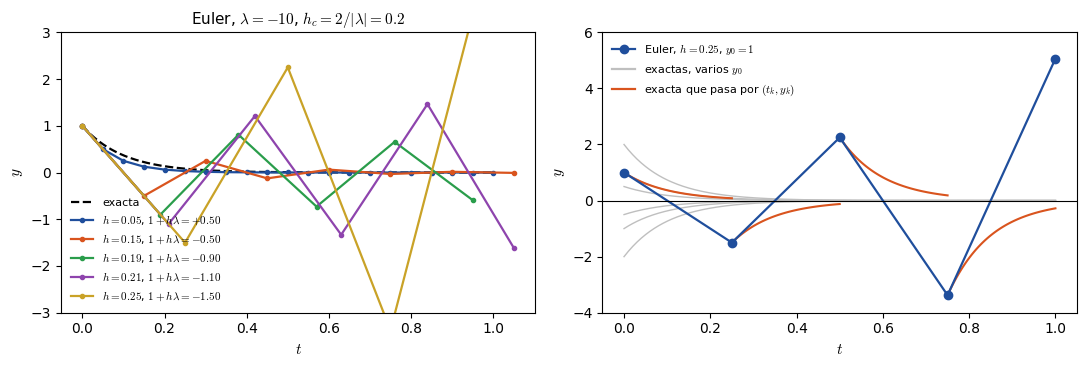

In [7]:
def factor_euler(lam, h):
    """Factor por el que Euler multiplica y en cada paso para y' = lam*y."""
    return 1 + h * lam

def h_critico(lam):
    """Mayor h para el que Euler es estable con y' = lam*y (lam < 0)."""
    return 2 / abs(lam)

lam = -10.0
f_lin = lambda t, y, lam: lam * y
tt = np.linspace(0, 1, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(tt, np.exp(lam * tt), "k--", label="exacta")
for h, c in zip([0.05, 0.15, 0.19, 0.21, 0.25], CICLO):
    t, y = euler_mio(f_lin, 0.0, 1.0, h, int(round(1 / h)), args=(lam,))
    ax1.plot(t, y[:, 0], "o-", ms=3, color=c, label=rf"$h={h}$, $1+h\lambda={factor_euler(lam, h):+.2f}$")
ax1.set_ylim(-3, 3); ax1.set_xlabel("$t$"); ax1.set_ylabel("$y$"); ax1.legend(fontsize=8, loc="lower left")
ax1.set_title(rf"Euler, $\lambda={lam:g}$, $h_c = 2/|\lambda| = {h_critico(lam)}$")

# caso malo: h = 0.25, con las soluciones exactas para varios y0 y el tramo exacto que sale de cada punto de Euler
h = 0.25
t, y = euler_mio(f_lin, 0.0, 1.0, h, 4, args=(lam,))
for y0 in [-2, -1, -0.5, 0.5, 1, 2]:
    ax2.plot(tt, y0 * np.exp(lam * tt), color="0.75", lw=1)
for k in range(4):
    s = np.linspace(t[k], t[k + 1], 50)
    ax2.plot(s, y[k, 0] * np.exp(lam * (s - t[k])), color=COLORES["nul_h"], lw=1.5)
ax2.plot(t, y[:, 0], "o-", color=COLORES["traj"], label=rf"Euler, $h={h}$, $y_0=1$")
ax2.plot([], [], color="0.75", label="exactas, varios $y_0$")
ax2.plot([], [], color=COLORES["nul_h"], label="exacta que pasa por $(t_k, y_k)$")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("$t$"); ax2.set_ylabel("$y$"); ax2.set_ylim(-4, 6); ax2.legend(fontsize=8, loc="upper left")
fig.tight_layout()

In [8]:
# Verificación
assert np.isclose(factor_euler(-10.0, 0.1), 0.0) and np.isclose(factor_euler(-10.0, 0.25), -1.5)
assert np.isclose(h_critico(-10.0), 0.2), "h crítico de lambda = -10 es 0.2"
_, y_mal = euler_mio(lambda t, y: -10.0 * y, 0.0, 1.0, 0.25, 8)
_, y_bien = euler_mio(lambda t, y: -10.0 * y, 0.0, 1.0, 0.1, 20)
assert abs(y_mal[-1, 0]) > 1 and abs(y_bien[-1, 0]) < 1e-3, "h = 0.25 debería explotar y h = 0.1 decaer"
print("factor de amplificación: OK")

factor de amplificación: OK


### Tarea 4: Una ecuación rígida: Euler explícito contra implícito

El ejercicio del texto con $\dot y = -50\,(y - \cos t)$, $y(0) = 0.15$, en $[0, 1]$. La solución exacta es

$$y(t) = \frac{2500\cos t + 50\sin t}{2501} + \Bigl(y_0 - \frac{2500}{2501}\Bigr)e^{-50t}:$$

un transitorio que muere en $t\approx 0.1$ y después, esencialmente, $\cos t$. Nada difícil de dibujar. Sin embargo:

1. Resolvé con `euler_mio` para $h = 0.1,\ 0.05,\ 0.04,\ 0.03,\ 0.01$ y graficá con la exacta. Antes de correr, predecí cuáles $h$ van a funcionar usando `h_critico(-50)`.
2. Implementá `euler_implicito_rigido(y0, h, n)` para esta ecuación: como $f$ es lineal en $y$, la ecuación $y_{k+1} = y_k + h f(t_{k+1}, y_{k+1})$ se despeja a mano. Graficá los mismos $h$.

**Qué se espera.** Que la predicción de estabilidad se cumpla (para $h = 0.04$ el factor es exactamente $-1$: ¿qué hace la solución numérica?), y que el implícito dé una curva razonable *para todos* los $h$, incluso $h = 0.1$, con un error visible pero chico (informá en la leyenda el error máximo sobre el intervalo). Anotá cuántos pasos necesita el explícito para ser aceptable y cuántos el implícito.

h crítico para lambda = -50: 0.04


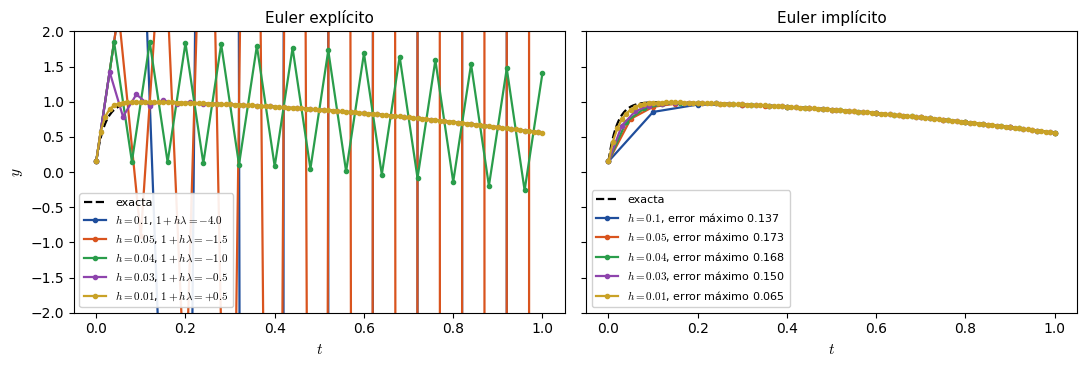

In [9]:
f_rigida = lambda t, y: -50.0 * (y - np.cos(t))
y_rigida = lambda t, y0=0.15: (2500 * np.cos(t) + 50 * np.sin(t)) / 2501 + (y0 - 2500 / 2501) * np.exp(-50 * t)

def euler_implicito_rigido(y0, h, n):
    """Euler implícito para y' = -50 (y - cos t). Devuelve (t, y) con y de forma (n+1,)."""
    t = h * np.arange(n + 1)
    y = np.zeros(n + 1)
    y[0] = y0
    for k in range(n):
        # y[k+1] = y[k] + h*(-50)*(y[k+1] - cos t[k+1])  =>  (1 + 50h) y[k+1] = y[k] + 50 h cos t[k+1]
        y[k + 1] = (y[k] + 50 * h * np.cos(t[k + 1])) / (1 + 50 * h)
    return t, y

print("h crítico para lambda = -50:", h_critico(-50.0))
tt = np.linspace(0, 1, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax in (ax1, ax2):
    ax.plot(tt, y_rigida(tt), "k--", label="exacta")
for h, c in zip([0.1, 0.05, 0.04, 0.03, 0.01], CICLO):
    n = int(round(1 / h))
    t, y = euler_mio(f_rigida, 0.0, 0.15, h, n)
    ax1.plot(t, y[:, 0], "o-", ms=3, color=c, label=rf"$h={h}$, $1+h\lambda={factor_euler(-50, h):+.1f}$")
    t, y = euler_implicito_rigido(0.15, h, n)
    ax2.plot(t, y, "o-", ms=3, color=c, label=rf"$h={h}$, error máximo {np.max(np.abs(y - y_rigida(t))):.3f}")
ax1.set_ylim(-2, 2); ax1.set_title("Euler explícito"); ax2.set_title("Euler implícito")
for ax in (ax1, ax2):
    ax.set_xlabel("$t$"); ax.legend(fontsize=8, loc="lower left", frameon=True, framealpha=0.9)
ax1.set_ylabel("$y$")
fig.tight_layout()

In [10]:
# Verificación
t_i, y_i = euler_implicito_rigido(0.15, 0.1, 10)
assert abs(y_i[-1] - y_rigida(1.0)) < 0.1, "el implícito con h = 0.1 debería quedar cerca de la exacta"
_, y_e = euler_mio(f_rigida, 0.0, 0.15, 0.05, 20)
assert abs(y_e[-1, 0]) > 10, "el explícito con h = 0.05 debería explotar (factor -1.5)"
print("Euler implícito: OK")

Euler implícito: OK


**Para el docente.** Dificultades típicas en las Tareas 3 y 4: (i) confundir "inestable" con "impreciso": insistir en que con $h=0.21$ el error es enorme aunque $h$ es apenas mayor que con $0.19$; (ii) en la figura 2 de la Tarea 3, dibujar la exacta con $y_0=1$ solamente: el punto es que cada paso de Euler parte de *otra* solución exacta; (iii) en el implícito, olvidar que el coseno se evalúa en $t_{k+1}$ (con $t_k$ funciona igual de estable pero es otro método y el error es distinto). Tiempo: Tareas 1–4, unas 100 minutos.

## 3. Más orden por paso: Runge–Kutta

Euler usa una sola evaluación de $f$ por paso y obtiene orden 1. La idea de **Runge–Kutta** es evaluar $f$ en varios puntos intermedios del intervalo $[t_k, t_{k+1}]$ y combinarlos de modo que la expansión de Taylor del resultado coincida con la de la solución exacta hasta un orden más alto.

**RK2 (punto medio, o Euler modificado).** Primero se estima la pendiente en el punto medio con un medio paso de Euler, y después se usa *esa* pendiente para dar el paso entero:

$$k_1 = f(t_k, y_k),\qquad k_2 = f\Bigl(t_k + \tfrac h2,\ y_k + \tfrac h2 k_1\Bigr),\qquad y_{k+1} = y_k + h\,k_2 .$$

Dos evaluaciones por paso, error local $O(h^3)$, error global $O(h^2)$: **orden 2**. Es el esquema que el ejercicio de la bolita del texto pide usar. El esquema de Heun del ejercicio de la población silvestre es otro RK2 con otros pesos.

**RK4 (el "clásico").** Cuatro evaluaciones por paso y orden 4:

$$\begin{aligned}
k_1 &= f(t_k, y_k), & k_2 &= f\bigl(t_k + \tfrac h2,\ y_k + \tfrac h2 k_1\bigr),\\
k_3 &= f\bigl(t_k + \tfrac h2,\ y_k + \tfrac h2 k_2\bigr), & k_4 &= f(t_k + h,\ y_k + h k_3),
\end{aligned}
\qquad y_{k+1} = y_k + \frac h6\,(k_1 + 2k_2 + 2k_3 + k_4).$$

Es una regla de Simpson para $\int_{t_k}^{t_{k+1}} f\,dt$ con las pendientes intermedias estimadas sucesivamente. Es el caballito de batalla de la integración numérica cuando no hay rigidez: `solve_ivp` usa por defecto un pariente suyo (`RK45`, Dormand–Prince).

**Costo y beneficio.** El costo de un método se mide en evaluaciones de $f$ (en un sistema grande, $f$ es lo caro). Con $n$ pasos, Euler hace $n$ evaluaciones, RK2 $2n$ y RK4 $4n$. Parece que RK4 es cuatro veces más caro, pero para una precisión dada $\varepsilon$ el paso que necesita cada uno es $h \sim \varepsilon^{1/p}$: para $\varepsilon = 10^{-8}$, Euler necesita $h\sim 10^{-8}$ (¡cien millones de pasos por unidad de tiempo!) y RK4, $h\sim 10^{-2}$. Por eso en la comparación honesta —error contra número de evaluaciones— RK4 gana por varios órdenes de magnitud salvo cuando la precisión requerida es muy baja.

**Errores típicos.** Usar $k_1$ en lugar de $k_2$ al dar el paso (eso es Euler disfrazado); evaluar $k_3$ con $k_1$ en lugar de $k_2$; olvidar el $h/2$ en el tiempo de $k_2$ y $k_3$ (no importa si $f$ no depende de $t$, pero en el ejercicio de la población silvestre sí). Un buen chequeo: con $f = f(t)$ solamente, RK4 tiene que reproducir la regla de Simpson.

**Estabilidad de RK.** Para $\dot y = \lambda y$ el factor de amplificación de RK4 es $R(z) = 1 + z + z^2/2 + z^3/6 + z^4/24$ con $z = h\lambda$, y $|R(z)|<1$ para $-2.79 < z < 0$: un poco mejor que Euler ($-2 < z < 0$), pero del mismo tipo. Los métodos explícitos, todos, tienen una región de estabilidad acotada: contra la rigidez no hay orden que valga, hace falta un método implícito.

### Tarea 5: RK2 y RK4, y la comparación de costos

Implementá `rk2_mio` y `rk4_mio` con la misma firma que `euler_mio`. Después, con `error_final` y `orden_empirico` de la Tarea 2 sobre la misma logística, medí el orden empírico de los tres métodos y armá dos gráficos log-log: error contra $h$ y error contra número de evaluaciones de $f$ ($n$, $2n$ y $4n$).

**Qué se espera.** Pendientes cercanas a 1, 2 y 4. Para RK4 con los $h$ más chicos el error puede llegar a $10^{-12}$ o menos y empezar a "aplanarse": es el error de redondeo de la aritmética de punto flotante, que ya no baja con $h$ (si pasa, medí la pendiente con los $h$ grandes). En el gráfico de error contra evaluaciones, RK4 tiene que quedar por debajo de los otros dos prácticamente en todo el rango: comentá qué precisión se logra con 100 evaluaciones con cada método.

Euler: orden empírico 1.07
RK2: orden empírico 2.04
RK4: orden empírico 4.04


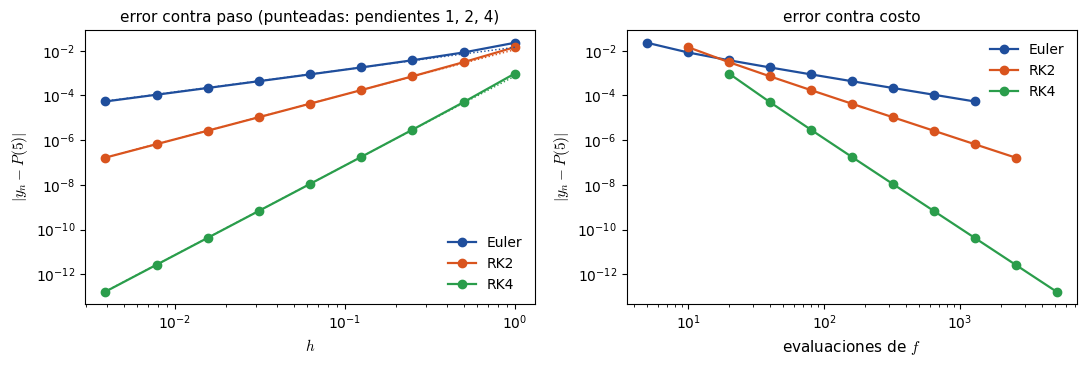

In [11]:
def rk2_mio(f, t0, y0, h, n, args=()):
    """Runge-Kutta de orden 2 (punto medio)."""
    y0 = np.atleast_1d(np.asarray(y0, dtype=float))
    t = t0 + h * np.arange(n + 1)
    y = np.zeros((n + 1, len(y0)))
    y[0] = y0
    for k in range(n):
        k1 = np.asarray(f(t[k], y[k], *args))
        k2 = np.asarray(f(t[k] + h / 2, y[k] + h / 2 * k1, *args))
        y[k + 1] = y[k] + h * k2
    return t, y

def rk4_mio(f, t0, y0, h, n, args=()):
    """Runge-Kutta clásico de orden 4."""
    y0 = np.atleast_1d(np.asarray(y0, dtype=float))
    t = t0 + h * np.arange(n + 1)
    y = np.zeros((n + 1, len(y0)))
    y[0] = y0
    for k in range(n):
        k1 = np.asarray(f(t[k], y[k], *args))
        k2 = np.asarray(f(t[k] + h / 2, y[k] + h / 2 * k1, *args))
        k3 = np.asarray(f(t[k] + h / 2, y[k] + h / 2 * k2, *args))
        k4 = np.asarray(f(t[k] + h, y[k] + h * k3, *args))
        y[k + 1] = y[k] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return t, y

metodos = {"Euler": (euler_mio, 1), "RK2": (rk2_mio, 2), "RK4": (rk4_mio, 4)}   # (función, evaluaciones por paso)
errores = {}
for nombre, (metodo, _) in metodos.items():
    errores[nombre] = error_final(metodo, logistica, P_exacta, 0.0, T, P0, hs, args=(r, K))
    print(f"{nombre}: orden empírico {orden_empirico(hs, errores[nombre]):.2f}")

n_pasos = np.round(T / hs)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for (nombre, (_, evals)), c in zip(metodos.items(), CICLO):
    ax1.loglog(hs, errores[nombre], "o-", color=c, label=nombre)
    ax2.loglog(evals * n_pasos, errores[nombre], "o-", color=c, label=nombre)
for (nombre, p), c in zip([("Euler", 1), ("RK2", 2), ("RK4", 4)], CICLO):
    ax1.loglog(hs, errores[nombre][3] * (hs / hs[3]) ** p, ":", color=c, lw=1)
ax1.set_xlabel("$h$"); ax1.set_ylabel("$|y_n - P(5)|$"); ax1.legend(); ax1.set_title("error contra paso (punteadas: pendientes 1, 2, 4)")
ax2.set_xlabel("evaluaciones de $f$"); ax2.set_ylabel("$|y_n - P(5)|$"); ax2.legend(); ax2.set_title("error contra costo")
fig.tight_layout()

In [12]:
# Verificación: coincidencia con imc.numerico y órdenes
t_a, y_a = rk4_mio(prueba, 0.0, [1.0, 0.0], 0.05, 200, args=(2.0,))
t_b, y_b = numerico.rk4(prueba, 0.0, [1.0, 0.0], 0.05, 200, args=(2.0,))
assert np.allclose(y_a, y_b), "rk4_mio no coincide con imc.numerico.rk4"
t_a, y_a = rk2_mio(prueba, 0.0, [1.0, 0.0], 0.05, 200, args=(2.0,))
t_b, y_b = numerico.rk2(prueba, 0.0, [1.0, 0.0], 0.05, 200, args=(2.0,))
assert np.allclose(y_a, y_b), "rk2_mio no coincide con imc.numerico.rk2"
p2 = orden_empirico(hs, errores["RK2"]); p4 = orden_empirico(hs[:6], errores["RK4"][:6])
assert 1.8 < p2 < 2.2, f"orden de RK2 {p2:.2f}, se esperaba ~2"
assert 3.7 < p4 < 4.3, f"orden de RK4 {p4:.2f}, se esperaba ~4"
print(f"RK2 orden {p2:.2f}, RK4 orden {p4:.2f}: OK")

RK2 orden 2.04, RK4 orden 4.07: OK


**Para el docente.** El orden de RK4 se mide con los seis $h$ más grandes porque con $h = 2^{-8}$ el error ya está cerca de $10^{-13}$ y el redondeo lo aplana; conviene mostrarlo como algo esperable y no como un fallo. Alguien va a proponer "entonces uso RK4 con $h$ enorme": la Tarea 6 (energía) y la región de estabilidad responden. Tiempo: 40 minutos.

## 4. Sistemas: ecuaciones de orden dos y la energía como diagnóstico

Nada de lo anterior cambia si $y\in\mathbb R^d$: las fórmulas de Euler y RK son las mismas con vectores, y por eso las escribimos con `np.asarray(f(...))`. Lo único que hay que saber es **cómo escribir una ecuación de orden dos como sistema**. Para el oscilador armónico amortiguado del texto (ejercicio "oscilador armónico"),

$$m\ddot x + b\dot x + kx = 0,$$

se define $v = \dot x$ y queda el sistema de primer orden

$$\dot x = v,\qquad \dot v = -\frac{k}{m}x - \frac{b}{m}v,$$

con estado $X = (x, v)$. El notebook `02-mecanicos` hace esto para el oscilador y el péndulo ($\dot\theta = \omega$, $\dot\omega = -\frac{g}{\ell}\sin\theta$) y dibuja los retratos de fase; acá no repetimos eso sino que usamos el oscilador como *banco de pruebas* de los métodos, porque conocemos la solución exacta. Con $\Delta = b^2 - 4mk$: $\Delta>0$ sobreamortiguado (dos exponenciales reales, sin oscilar), $\Delta = 0$ crítico, $\Delta<0$ subamortiguado (oscilación con amplitud $e^{-bt/2m}$).

**La energía como diagnóstico.** Sin rozamiento ($b = 0$) la energía $E = \tfrac12 m v^2 + \tfrac12 k x^2$ se conserva exactamente: la solución recorre una elipse en el plano $(x,v)$ para siempre. Ningún método numérico la conserva exactamente, y lo que le hace a $E$ es una radiografía de su error: para $\dot y = \lambda y$ con $\lambda = i\omega$ imaginario puro (que es lo que es el oscilador, escrito en forma compleja), el factor de amplificación de Euler es $|1 + i h\omega| = \sqrt{1 + h^2\omega^2} > 1$ para *cualquier* $h$. Euler siempre infla la energía: la elipse se convierte en una espiral hacia afuera, con $E$ creciendo como $e^{\omega^2 h t}$. En una simulación larga (el ítem 4 del ejercicio pide $t\in[0,1000]$) esto es catastrófico. RK4 tiene $|R(i h\omega)| = 1 - \tfrac{(h\omega)^6}{144} + \dots < 1$: pierde energía, pero muchísimo más despacio, y con $h$ moderado la deriva es despreciable en tiempos largos.

Existe una familia de métodos, los **integradores simplécticos**, diseñados para sistemas mecánicos, que no conservan $E$ exactamente pero mantienen su error acotado para siempre (oscila en lugar de derivar). El más simple es el *Euler simpléctico*: actualizar $v$ con Euler y después $x$ con la $v$ *nueva*. Lo mostramos abajo como lectura; para simulaciones de mecánica celeste o dinámica molecular son la norma.

### Tarea 6: El oscilador amortiguado como sistema

Escribí `oscilador(t, X, m, b, k)`, el campo del sistema para $m\ddot x + b\dot x + kx = 0$ con $X = (x, v)$, y `energia(X, m, k)` que devuelva $E$ para un array `X` de forma `(n+1, 2)` (una fila por instante). Después:

1. Con `rk4_mio`, $h = 0.01$, $t\in[0, 20]$, $m = k = 1$, $x(0) = 1$, $\dot x(0) = 0$: resolvé para $b = 3$, $b = 2$ y $b = 1$ (calculá $\Delta$ en cada caso) y graficá $x(t)$ en la misma figura. Tiene que verse el sobreamortiguado, el crítico y el subamortiguado.
2. Con $b = 0$, $m = k = 1$, $t\in[0, 1000]$ y $h = 0.05$: resolvé con `euler_mio`, `rk2_mio` y `rk4_mio` y graficá $E(t)/E(0)$ en escala logarítmica para los tres. Calculá también el factor $\sqrt{1 + h^2}$ elevado a $n$ y compará con lo que le pasa a Euler.

**Qué se espera.** En 1, curvas suaves que coinciden con la teoría (para $b=1$ la exacta es $e^{-t/2}\bigl(\cos\omega t + \tfrac{1}{2\omega}\sin\omega t\bigr)$ con $\omega = \sqrt3/2$; la verificación la usa). En 2, Euler con $E$ creciendo exponencialmente (¡decenas de órdenes de magnitud!), RK2 también creciendo pero mucho más despacio, y RK4 prácticamente constante. Anotá cuánto se aparta $E$ de $E(0)$ con RK4 al final.

E(1000)/E(0): {'Euler': '4.87109e+21', 'RK2': '1.03174', 'RK4': '0.999996'}


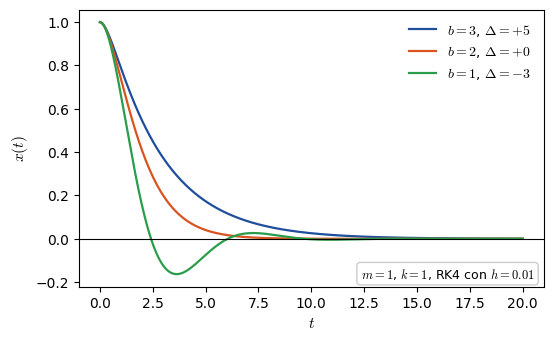

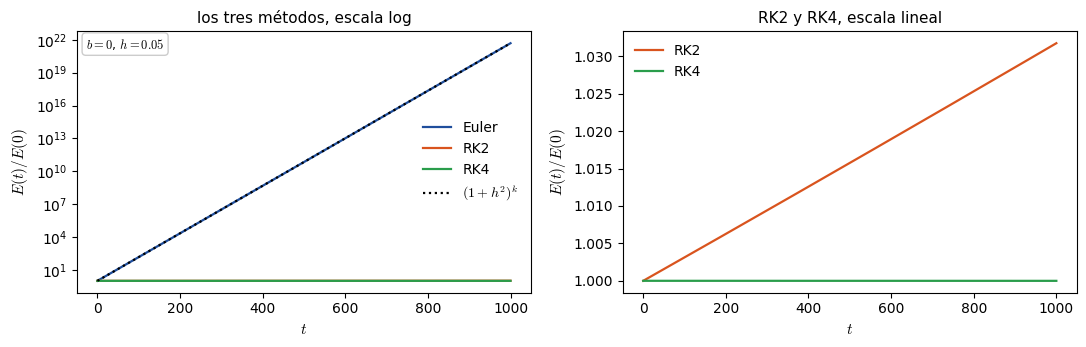

In [13]:
def oscilador(t, X, m, b, k):
    """Campo del sistema de primer orden para m x'' + b x' + k x = 0, X = (x, v)."""
    x, v = X
    return [v, -(k / m) * x - (b / m) * v]

def energia(X, m, k):
    """E = m v^2 / 2 + k x^2 / 2 para un array X de forma (n+1, 2)."""
    return 0.5 * m * X[:, 1] ** 2 + 0.5 * k * X[:, 0] ** 2

m, k = 1.0, 1.0
fig, ax = plt.subplots(figsize=(6, 3.6))
for b in [3.0, 2.0, 1.0]:
    t, X = rk4_mio(oscilador, 0.0, [1.0, 0.0], 0.01, 2000, args=(m, b, k))
    ax.plot(t, X[:, 0], label=rf"$b = {b:g}$, $\Delta = {b**2 - 4*m*k:+g}$")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("$t$"); ax.set_ylabel("$x(t)$"); ax.legend()
estilo.parametros(ax, rf"$m = {m:g}$, $k = {k:g}$, RK4 con $h = 0.01$", loc="lower right")

h, n = 0.05, 20000
fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(11, 3.6))
E_final = {}
for (nombre, (metodo, _)), c in zip(metodos.items(), CICLO):
    t, X = metodo(oscilador, 0.0, [1.0, 0.0], h, n, args=(m, 0.0, k))
    E = energia(X, m, k)
    E_final[nombre] = E[-1] / E[0]
    ax2.semilogy(t, E / E[0], color=c, label=nombre)
    if nombre != "Euler":
        ax3.plot(t, E / E[0], color=c, label=nombre)
ax2.semilogy(t, (1 + h ** 2) ** (np.arange(n + 1)), "k:", label=r"$(1+h^2)^{k}$")
ax2.set_xlabel("$t$"); ax2.set_ylabel("$E(t)/E(0)$"); ax2.legend(); ax2.set_title("los tres métodos, escala log")
ax3.set_xlabel("$t$"); ax3.set_ylabel("$E(t)/E(0)$"); ax3.legend(); ax3.set_title("RK2 y RK4, escala lineal")
estilo.parametros(ax2, rf"$b = 0$, $h = {h}$", loc="upper left")
fig2.tight_layout()
print("E(1000)/E(0):", {k_: f"{v:.6g}" for k_, v in E_final.items()})

In [14]:
# Verificación: exacta del caso subamortiguado y comportamiento de la energía
w = np.sqrt(3) / 2
t, X = rk4_mio(oscilador, 0.0, [1.0, 0.0], 0.01, 2000, args=(1.0, 1.0, 1.0))
x_ex = np.exp(-t / 2) * (np.cos(w * t) + np.sin(w * t) / (2 * w))
assert np.max(np.abs(X[:, 0] - x_ex)) < 1e-6, "RK4 con h = 0.01 debería coincidir con la exacta a 1e-6"
_, Xe = euler_mio(oscilador, 0.0, [1.0, 0.0], 0.05, 2000, args=(1.0, 0.0, 1.0))
_, X4 = rk4_mio(oscilador, 0.0, [1.0, 0.0], 0.05, 2000, args=(1.0, 0.0, 1.0))
Ee, E4 = energia(Xe, 1.0, 1.0), energia(X4, 1.0, 1.0)
assert Ee[-1] / Ee[0] > 10, "Euler debería inflar la energía"
assert abs(E4[-1] / E4[0] - 1) < 1e-4, "RK4 debería conservar la energía a 1e-4 en t = 100"
print("oscilador y energía: OK")

oscilador y energía: OK


### Lectura: Euler simpléctico

Mismo costo que Euler (una evaluación por paso), mismo orden 1, pero la energía no deriva: oscila alrededor del valor exacto con amplitud $O(h)$, por siempre. La razón profunda es que el mapa $(x_k, v_k)\mapsto(x_{k+1}, v_{k+1})$ conserva el área en el plano de fases, como lo hace el flujo exacto de un sistema mecánico sin rozamiento. Corré la celda y comparalo con la figura de la Tarea 6.

Euler simpléctico, t = 1000: E/E0 en [0.9756, 1.0256]


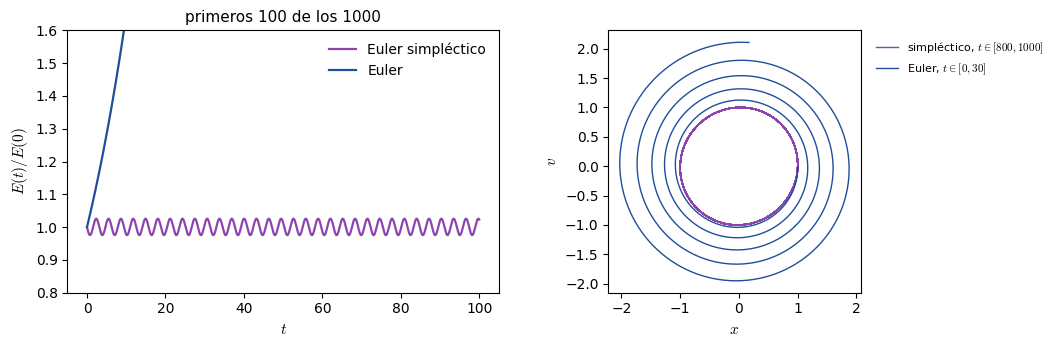

In [15]:
def euler_simplectico(x0, v0, h, n, m=1.0, k=1.0):
    """Euler simpléctico para m x'' + k x = 0: primero v con Euler, después x con la v nueva."""
    x, v = np.zeros(n + 1), np.zeros(n + 1)
    x[0], v[0] = x0, v0
    for j in range(n):
        v[j + 1] = v[j] - h * (k / m) * x[j]
        x[j + 1] = x[j] + h * v[j + 1]
    return h * np.arange(n + 1), np.column_stack([x, v])

h, n = 0.05, 20000
t, Xs = euler_simplectico(1.0, 0.0, h, n)
_, Xe = euler_mio(oscilador, 0.0, [1.0, 0.0], h, n, args=(1.0, 0.0, 1.0))
Es, Ee = energia(Xs, 1.0, 1.0), energia(Xe, 1.0, 1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(t[:2000], Es[:2000] / Es[0], label="Euler simpléctico", color=CICLO[3])
ax1.plot(t[:2000], Ee[:2000] / Ee[0], label="Euler", color=CICLO[0])
ax1.set_ylim(0.8, 1.6); ax1.set_xlabel("$t$"); ax1.set_ylabel("$E(t)/E(0)$"); ax1.legend(); ax1.set_title("primeros 100 de los 1000")
ax2.plot(Xs[-4000:, 0], Xs[-4000:, 1], color=CICLO[3], lw=1, label="simpléctico, $t \\in [800, 1000]$")
ax2.plot(Xe[:600, 0], Xe[:600, 1], color=CICLO[0], lw=1, label="Euler, $t \\in [0, 30]$")
ax2.set_xlabel("$x$"); ax2.set_ylabel("$v$"); ax2.set_aspect("equal"); ax2.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
print(f"Euler simpléctico, t = 1000: E/E0 en [{Es.min()/Es[0]:.4f}, {Es.max()/Es[0]:.4f}]")

## 5. En la práctica: `scipy.integrate.solve_ivp`

Lo que hicimos hasta acá explica qué hay adentro de un integrador profesional, pero nadie usa `rk4_mio` para trabajar. `solve_ivp(f, (t0, T), y0, ...)` hace lo mismo con tres agregados fundamentales:

* **Paso adaptativo.** El método por defecto, `RK45`, calcula en cada paso *dos* aproximaciones (de orden 4 y 5) con las mismas evaluaciones; la diferencia estima el error local, y el paso $h$ se agranda o se achica para que ese error quede dentro de la tolerancia. Así, $h$ es chico donde la solución cambia rápido y grande donde es suave, sin que nosotros lo elijamos. Por eso `sol.t` no es equiespaciado.
* **Tolerancias.** `rtol` (relativa, por defecto $10^{-3}$) y `atol` (absoluta, por defecto $10^{-6}$): el error local por componente se mantiene por debajo de $\text{atol} + \text{rtol}\cdot|y|$. El defecto es *bajo* para lo que solemos querer: en los notebooks del curso usamos `rtol=1e-8` o menos. `atol` importa cuando alguna componente pasa cerca de cero (una población que se extingue: con `atol` grande, el error absoluto permitido es mayor que el valor).
* **Métodos.** `RK45` (defecto), `RK23` (orden bajo, para tolerancias flojas), `DOP853` (orden 8, para tolerancias muy exigentes) son explícitos; `Radau`, `BDF` y `LSODA` sirven para problemas rígidos. Una regla práctica: si `RK45` tarda mucho o `sol.nfev` es enorme para una solución que se ve suave, el problema es rígido y hay que pasar a `Radau` o `BDF`.
* **Salida.** `sol.t`, `sol.y` (forma `(dim, len(t))`: ¡transpuesta respecto de nuestras funciones!), `sol.nfev` (evaluaciones de $f$), `sol.success`. Con `dense_output=True`, `sol.sol(t)` es una interpolación continua de la solución que podés evaluar en cualquier $t$ (los notebooks del curso la usan para graficar en una grilla fina). `t_eval=` pide la solución en instantes dados sin cambiar los pasos internos.
* **Eventos.** `events=[g]` con `g(t, y)` una función escalar: el integrador detecta con precisión los instantes en que $g$ cruza cero (los devuelve en `sol.t_events`, y el estado en `sol.y_events`). Con `g.terminal = True` la integración se detiene en el primer cruce; con `g.direction = -1` (o `+1`) solo cuenta los cruces decrecientes (o crecientes). Es *la* herramienta para "¿cuándo llega al piso?", "¿cuándo cruza $y = 0$ hacia arriba?" (período de una órbita), "¿cuándo empieza a bajar la curva de infectados?" (cruce de $\dot I = 0$), y para simular choques: se integra hasta el evento, se modifica el estado y se vuelve a arrancar.

La celda siguiente muestra tolerancias y costo sobre la logística (error real contra `rtol`) y el efecto de la rigidez sobre `RK45` contra `Radau`.

In [16]:
# Tolerancias: error real y costo en la logística (solución exacta conocida)
print("rtol      error en T   nfev")
for rtol in [1e-3, 1e-5, 1e-7, 1e-9, 1e-11]:
    sol = solve_ivp(logistica, (0, T), [P0], args=(r, K), rtol=rtol, atol=1e-12)
    print(f"{rtol:.0e}   {abs(sol.y[0, -1] - P_exacta(T)):.1e}     {sol.nfev}")

# Rigidez: y' = -1000 (y - cos t) en [0, 10]; la solución es esencialmente cos t
f_muy_rigida = lambda t, y: -1000.0 * (y - np.cos(t))
print("\nmétodo   nfev   tiempo [s]   (y' = -1000 (y - cos t), rtol = 1e-6)")
for metodo in ["RK45", "DOP853", "Radau", "BDF"]:
    t0_ = time.perf_counter()
    sol = solve_ivp(f_muy_rigida, (0, 10), [0.0], method=metodo, rtol=1e-6, atol=1e-9)
    print(f"{metodo:7s}  {sol.nfev:5d}   {time.perf_counter() - t0_:.3f}")

rtol      error en T   nfev
1e-03   7.2e-05     32
1e-05   1.0e-06     62
1e-07   3.5e-09     128
1e-09   1.0e-10     302
1e-11   1.4e-12     668

método   nfev   tiempo [s]   (y' = -1000 (y - cos t), rtol = 1e-6)


RK45     21548   0.145


DOP853   28466   0.159
Radau      624   0.017
BDF        478   0.023


### Tarea 7: Pelota que rebota: eventos

El ejercicio "bouncing ball" del texto. Una pelota en caída libre, $\ddot x = -g$, con estado $(x, v)$, que rebota en el piso $x = 0$. Escribí `rebotes(x0, v0, e=1.0, T=10.0, g=9.81)` que:

1. integre con `solve_ivp` desde el estado actual hasta `T` con un evento `suelo(t, X)` que devuelva $x$, con `terminal = True` y `direction = -1` (solo cruces hacia abajo);
2. si hubo evento, invierta la velocidad multiplicándola por el coeficiente de restitución $e$ ($v\mapsto -e\,v$), ponga $x = 0$ y vuelva a integrar desde ahí;
3. devuelva los arrays concatenados `t`, `x`, `v` y la lista de instantes de rebote.

Usá `dense_output=True` o `max_step` chico para que la curva se vea suave. Corré en $[0, 12]$ con $x_0 = 5$, $v_0 = 0$ para $e = 1$ (elástico, cinco o seis rebotes) y $e = 0.8$, y graficá $x(t)$ de las dos.

**Qué se espera.** Para $e=1$, parábolas idénticas y rebotes en $t_1 = \sqrt{2x_0/g}$, $t_1 + 2t_1$, $t_1 + 4t_1$, ... (la verificación lo usa). Para $e = 0.8$, la altura máxima de cada vuelo se reduce en el factor $e^2$ y los rebotes se acumulan: la suma de los tiempos de vuelo es geométrica y converge, así que en tiempo finito hay infinitos rebotes (la *paradoja de Zenón*). Tu función tiene que cortar en algún momento: por ejemplo, cuando la velocidad después del rebote es menor que un umbral. Calculá a mano el instante de acumulación (suma de la serie geométrica de los tiempos de vuelo, $t_1 + 2t_1\sum_{j\ge1} e^j$) y comparalo con el último rebote que registró tu función. Describí cómo cortaste y qué pasa si no se corta.

e = 1.0: 6 rebotes, los primeros en t = [ 1.01   3.029  5.048  7.067  9.087 11.106]; último en t = 11.1060
e = 0.8: 42 rebotes, los primeros en t = [1.01  2.625 3.917 4.951 5.778 6.44  6.969 7.393]; último en t = 9.0859


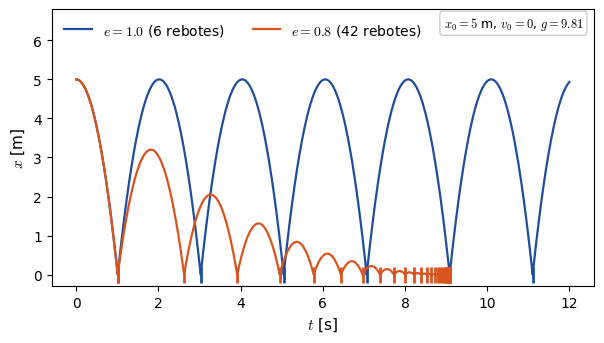

In [17]:
def rebotes(x0, v0, e=1.0, T=10.0, g=9.81, v_min=1e-3):
    """Caída libre con rebotes en x = 0. Devuelve (t, x, v, t_rebotes)."""
    def caida(t, X):
        return [X[1], -g]
    def suelo(t, X):
        return X[0]
    suelo.terminal = True
    suelo.direction = -1
    ts, xs, vs, t_reb = [], [], [], []
    t_act, X_act = 0.0, [x0, v0]
    while t_act < T:
        sol = solve_ivp(caida, (t_act, T), X_act, events=suelo, max_step=0.02, rtol=1e-10, atol=1e-12)
        ts.append(sol.t); xs.append(sol.y[0]); vs.append(sol.y[1])
        if sol.status != 1:          # llegó a T sin evento
            break
        t_act = sol.t_events[0][0]
        v_choque = sol.y_events[0][0][1]
        t_reb.append(t_act)
        X_act = [0.0, -e * v_choque]
        if abs(X_act[1]) < v_min:    # Zenón: cortar cuando ya casi no rebota
            break
    return np.concatenate(ts), np.concatenate(xs), np.concatenate(vs), np.array(t_reb)

fig, ax = plt.subplots(figsize=(7, 3.6))
for e, c in zip([1.0, 0.8], CICLO):
    t, x, v, tr = rebotes(5.0, 0.0, e=e, T=12.0)
    ax.plot(t, x, color=c, label=f"$e = {e}$ ({len(tr)} rebotes)")
    ax.plot(tr, np.zeros_like(tr), "|", ms=12, color=c, mew=2)
    print(f"e = {e}: {len(tr)} rebotes, los primeros en t = {np.round(tr[:8], 3)}; último en t = {tr[-1]:.4f}")
ax.set_xlabel("$t$ [s]"); ax.set_ylabel("$x$ [m]"); ax.set_ylim(-0.3, 6.8); ax.legend(loc="upper left", ncol=2)
estilo.parametros(ax, r"$x_0 = 5$ m, $v_0 = 0$, $g = 9.81$", loc="upper right")

In [18]:
# Verificación: instantes de rebote del caso elástico
t, x, v, tr = rebotes(5.0, 0.0, e=1.0, T=12.0)
t1 = np.sqrt(2 * 5.0 / 9.81)
esperados = t1 * (1 + 2 * np.arange(len(tr)))
assert len(tr) >= 5, "se esperaban al menos 5 rebotes en 12 s"
assert np.allclose(tr, esperados, atol=1e-6), f"rebotes en {tr}, se esperaba {esperados}"
assert x.min() > -1e-6, "la pelota atravesó el piso"
t, x, v, tr = rebotes(5.0, 0.0, e=0.8, T=12.0)
assert len(tr) > 5 and len(tr) < 200, "con e = 0.8 los rebotes se acumulan: hay que cortar"
t_zenon = t1 * (1 + 2 * 0.8 / (1 - 0.8))   # suma de la serie geométrica de tiempos de vuelo
assert tr[-1] < t_zenon < tr[-1] + 0.05, f"los rebotes deberían acumularse en t = {t_zenon:.3f}"
print("rebotes: OK")

rebotes: OK


**Para el docente.** Errores frecuentes en la Tarea 7: (i) olvidar `terminal = True` (entonces `solve_ivp` sigue integrando bajo el piso y devuelve todos los cruces de una parábola que ya no tiene sentido); (ii) reiniciar desde `sol.y[:, -1]` en lugar de `sol.y_events`, que es lo mismo aquí pero no si se usa `t_eval`; (iii) un bucle infinito con $e<1$ cuando el intervalo de integración se hace de longitud cero (por eso el corte por `v_min`). Con `max_step` chico la curva se ve suave; la alternativa es `dense_output=True` y evaluar en una grilla, pero hay que evaluar solo hasta `t_events`. Tiempo: 40 minutos.

### Tarea 8: SIR y SEIR en Macondo

Los ejercicios SIR y SEIR del texto. Macondo tiene $N = 10000$ habitantes, todos susceptibles salvo uno infectado. Tasa de contagio $\beta = 0.2$ por día, tiempo medio de recuperación $1/\gamma = 10$ días, y en la variante SEIR un tiempo medio de incubación $1/\sigma = 2$ días. Con el tiempo en días:

1. Escribí `sir(t, u, p)` con $u = (S, I, R)$ y `p = (beta, gamma, N)`, y `seir(t, u, p)` con $u = (S, E, I, R)$ y `p = (beta, sigma, gamma, N)`. Fijate que `solve_ivp` pasa los parámetros con `args=(p,)`: la coma importa.
2. Antes de simular, escribí en dos líneas cómo esperás que evolucionen $S$, $I$ y $R$ (¿hay epidemia? ¿de qué depende? El texto define $R_0 = \beta/\gamma$).
3. Simulá los dos modelos en $[0, 200]$ con `rtol=1e-8`, `dense_output=True` y un evento **no terminal** `pico(t, u, p)` que devuelva $\dot I$ (el lado derecho de la ecuación de $I$) con `direction = -1`: el instante en que $I$ deja de crecer. Graficá $S, I, R$ de los dos modelos (y $E$ del SEIR) en la misma figura y marcá los picos.
4. Verificá que $S + I + R$ (o $S + E + I + R$) se mantiene igual a $N$ a lo largo de la simulación, e informá el día del pico y el valor de $S$ en ese instante para cada modelo.
5. Medí, para el SIR, tiempo de cómputo (`time.perf_counter()`), `nfev` y error en $I(200)$ respecto de una solución de referencia (`DOP853` con `rtol=1e-12`) para los métodos `RK45`, `RK23`, `DOP853` y `rtol` en $10^{-3}, 10^{-6}, 10^{-9}$ (con `atol = 1e-6`).

**Qué se espera.** Una epidemia con pico alrededor del día 90 en el SIR y un mes más tarde en el SEIR (la incubación retrasa todo y aplana un poco el pico). En el SIR, en el instante del pico $\dot I = 0$ implica $S = \gamma N/\beta = N/R_0$: comprobalo con el valor que informe tu evento (es la verificación). En el SEIR eso ya no vale exactamente: cuando $S$ cruza $N/R_0$ todavía hay expuestos "en la cola" que van a pasar a $I$, así que $I$ sigue subiendo un poco más y en su pico $S$ es *menor* que $N/R_0$ (la verificación chequea que sea menor, pero no por mucho). La conservación de $N$ se va a cumplir a nivel de redondeo ($\sim 10^{-11}$), mucho mejor que la tolerancia: explicá por qué (pista: sumá las ecuaciones y pensá qué hace un paso de Runge–Kutta con esa suma). En la tabla del ítem 5, `DOP853` tiene que ser el más barato para `rtol` chico y `RK23` el peor.

SIR: pico el día 90.7, S en el pico = 5000.0 (N/R0 = 5000), I en el pico = 1535; |suma - N| máx = 5.46e-12
SEIR: pico el día 121.2, S en el pico = 4791.2 (N/R0 = 5000), I en el pico = 1275; |suma - N| máx = 1.09e-11

método   rtol    tiempo [ms]   nfev   |I(200) - ref|
RK45     1e-03        1.0       104   1.82e-01
RK45     1e-06        2.5       350   1.38e-06
RK45     1e-09        5.5       782   5.89e-07
RK23     1e-03        1.2       122   2.51e-01
RK23     1e-06       13.0      1103   2.88e-05
RK23     1e-09       50.7      5240   4.28e-06
DOP853   1e-03        1.2       158   8.11e-05
DOP853   1e-06        2.2       242   1.57e-06
DOP853   1e-09        2.7       410   3.80e-07


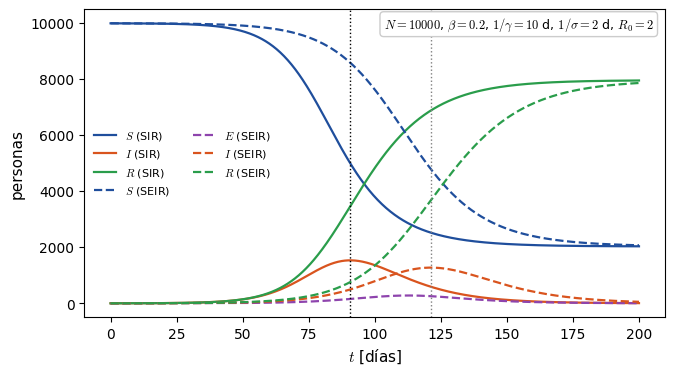

In [19]:
def sir(t, u, p):
    beta, gamma, N = p
    S, I, R = u
    return [-beta * S * I / N, beta * S * I / N - gamma * I, gamma * I]

def seir(t, u, p):
    beta, sigma, gamma, N = p
    S, E, I, R = u
    return [-beta * S * I / N, beta * S * I / N - sigma * E, sigma * E - gamma * I, gamma * I]

N, beta, gamma, sigma = 10000, 0.2, 1 / 10, 1 / 2
p_sir, p_seir = (beta, gamma, N), (beta, sigma, gamma, N)

def pico_sir(t, u, p):
    return sir(t, u, p)[1]
pico_sir.direction = -1

def pico_seir(t, u, p):
    return seir(t, u, p)[2]
pico_seir.direction = -1

T_fin = 200.0
sol_sir = solve_ivp(sir, (0, T_fin), [N - 1, 1, 0], args=(p_sir,), rtol=1e-8, atol=1e-6, dense_output=True, events=pico_sir)
sol_seir = solve_ivp(seir, (0, T_fin), [N - 1, 0, 1, 0], args=(p_seir,), rtol=1e-8, atol=1e-6, dense_output=True, events=pico_seir)
tt = np.linspace(0, T_fin, 1000)
S1, I1, R1 = sol_sir.sol(tt)
S2, E2, I2, R2 = sol_seir.sol(tt)

fig, ax = plt.subplots(figsize=(7.5, 4))
for y, nombre, c in [(S1, "$S$", CICLO[0]), (I1, "$I$", CICLO[1]), (R1, "$R$", CICLO[2])]:
    ax.plot(tt, y, color=c, label=nombre + " (SIR)")
for y, nombre, c in [(S2, "$S$", CICLO[0]), (E2, "$E$", CICLO[3]), (I2, "$I$", CICLO[1]), (R2, "$R$", CICLO[2])]:
    ax.plot(tt, y, "--", color=c, label=nombre + " (SEIR)")
for sol, ev, c in [(sol_sir, pico_sir, "black"), (sol_seir, pico_seir, "0.5")]:
    tp = sol.t_events[0][0]
    ax.axvline(tp, color=c, ls=":", lw=1)
ax.set_xlabel("$t$ [días]"); ax.set_ylabel("personas"); ax.legend(ncol=2, fontsize=8)
estilo.parametros(ax, rf"$N={N}$, $\beta={beta}$, $1/\gamma={1/gamma:g}$ d, $1/\sigma={1/sigma:g}$ d, $R_0={beta/gamma:g}$", loc="upper right")

for nombre, sol, ev in [("SIR", sol_sir, 0), ("SEIR", sol_seir, 0)]:
    tp = sol.t_events[0][0]; up = sol.y_events[0][0]
    print(f"{nombre}: pico el día {tp:.1f}, S en el pico = {up[0]:.1f} (N/R0 = {N * gamma / beta:.0f}), I en el pico = {up[-2]:.0f}; "
          f"|suma - N| máx = {np.max(np.abs(sol.y.sum(axis=0) - N)):.2e}")

# Costo y precisión de los métodos
ref = solve_ivp(sir, (0, T_fin), [N - 1, 1, 0], args=(p_sir,), method="DOP853", rtol=1e-12, atol=1e-10)
I_ref = ref.y[1, -1]
print("\nmétodo   rtol    tiempo [ms]   nfev   |I(200) - ref|")
for metodo in ["RK45", "RK23", "DOP853"]:
    for rtol in [1e-3, 1e-6, 1e-9]:
        t0_ = time.perf_counter()
        s = solve_ivp(sir, (0, T_fin), [N - 1, 1, 0], args=(p_sir,), method=metodo, rtol=rtol, atol=1e-6)
        dt_ = (time.perf_counter() - t0_) * 1e3
        print(f"{metodo:7s}  {rtol:.0e}   {dt_:8.1f}     {s.nfev:5d}   {abs(s.y[1, -1] - I_ref):.2e}")

In [20]:
# Verificación: S en el pico = N / R0 y conservación de N
S_star = N * gamma / beta
for nombre, sol in [("SIR", sol_sir), ("SEIR", sol_seir)]:
    assert len(sol.t_events[0]) == 1, f"{nombre}: se esperaba exactamente un pico"
    assert np.max(np.abs(sol.y.sum(axis=0) - N)) < 1e-2, f"{nombre}: N no se conserva"
S_sir = sol_sir.y_events[0][0][0]; S_seir = sol_seir.y_events[0][0][0]
assert abs(S_sir - S_star) < 20, f"SIR: S en el pico = {S_sir:.1f}, se esperaba {S_star:.0f}"
assert 0.9 * S_star < S_seir < S_star, f"SEIR: S en el pico = {S_seir:.1f}, se esperaba un poco menos que {S_star:.0f}"
assert sol_seir.t_events[0][0] > sol_sir.t_events[0][0], "el pico del SEIR debería ser más tardío"
print("SIR/SEIR: OK")

SIR/SEIR: OK


**Para el docente.** El SIR con $I_0 = 1$ e $I$ del orden de miles: `atol=1e-6` es irrelevante frente a `rtol`; vale la pena preguntar qué pasaría con `atol=1` (nada visible) y con `atol=100` al principio, cuando $I\approx 1$. La conservación de $N$ se cumple a $10^{-11}$ (redondeo puro, no la tolerancia) porque las ecuaciones suman cero exactamente y todo método RK es lineal en $f$: la suma de las componentes se propaga con incremento exactamente cero. Sirve para discutir la diferencia entre lo que el método conserva por estructura (cantidades lineales) y lo que no (la energía de la Tarea 6, cuadrática). En la tabla del ítem 5, por debajo de $\sim 5\cdot 10^{-7}$ los errores dejan de bajar: es el error de la propia referencia (`rtol=1e-12` sobre valores del orden de $10^4$); no es un defecto de los métodos. Sobre el evento: algún grupo va a poner `direction = +1` y no va a encontrar nada; es la oportunidad de explicar el signo. Tiempo: 45 minutos.

## Interpretación

Esta es la parte que se evalúa. Respondé en las celdas de texto que siguen, con oraciones completas y citando los números o gráficos que obtuviste.

**1.** **Orden y costo.** Con los datos de la Tarea 5: ¿cuántas evaluaciones de $f$ necesita cada método para un error de $10^{-6}$ en $P(5)$? (Extrapolá con la pendiente si hace falta.) Explicá, a partir de la definición de orden, por qué cuadruplicar el trabajo por paso puede salir más barato.

**2.** **Estabilidad no es precisión.** En la Tarea 4, con $h = 0.05$ el error de Euler explícito es $O(h)$ según la teoría del orden, y sin embargo la solución numérica explota. ¿Qué hipótesis de la teoría del orden falla? ¿Qué determina el $h$ máximo en la ecuación rígida, y por qué el implícito no tiene ese límite? ¿Qué método de `solve_ivp` elegirías para la ecuación $\dot y = -1000(y - \cos t)$ y en qué te basás (citá los `nfev` de la celda de tolerancias)?

**3.** **Energía.** En la Tarea 6, Euler multiplica la energía por $1 + h^2$ en cada paso. Con $h = 0.05$ y $t = 1000$, ¿por cuánto la multiplicó al final, y coincide con lo que mediste? Si tuvieras que simular un planeta durante un millón de años, ¿qué integrador usarías y por qué no alcanza con «RK4 con $h$ chico»? ¿Qué te dice el gráfico del Euler simpléctico al respecto?

**4.** **SIR contra SEIR.** Con los números de la Tarea 8: ¿cuánto se retrasa el pico al incluir la incubación, y cambia el tamaño final de la epidemia ($R(200)$)? Explicá por qué en el SIR el pico ocurre exactamente cuando $S = N/R_0$, por qué en el SEIR ocurre un poco después (con $S$ menor), y qué información da eso a un epidemiólogo que solo ve la curva de infectados. ¿Qué haría más útil al modelo que las tolerancias de `solve_ivp`?

### Respuestas modelo (para el docente)

**1.** Con $T = 5$: para $10^{-6}$, Euler necesita $h\sim 10^{-6}\cdot(\text{cte})$, del orden de $10^{6}$–$10^{7}$ evaluaciones; RK2, $h\sim 10^{-3}$, unos $10^4$; RK4, $h\sim 0.03$–$0.1$, entre 200 y 700 evaluaciones (los números exactos salen de extrapolar las rectas del gráfico de error contra evaluaciones). El costo por paso se multiplica por 4 pero el número de pasos para una precisión $\varepsilon$ va como $\varepsilon^{-1/p}$: pasar de $p = 1$ a $p = 4$ reduce los pasos de $\varepsilon^{-1}$ a $\varepsilon^{-1/4}$, que para $\varepsilon$ chico compensa cualquier factor constante.

**2.** La teoría del orden dice que el error es $\le C h$ con $C$ que depende de $T$ y de $f$ (a través de $e^{LT}$, con $L = 50$ la constante de Lipschitz): la cota vale, pero es $e^{50}\cdot h$, inútil. La estabilidad es una pregunta para $h$ fijo: el factor $1 + h\lambda$ tiene que tener módulo menor que 1, lo que exige $h < 2/50 = 0.04$ aunque la solución sea $\cos t$, suave y lenta. El implícito tiene factor $1/(1 - h\lambda)$, de módulo $<1$ siempre. Para $\lambda = -1000$: `Radau` o `BDF`; la celda muestra `RK45` con miles de `nfev` (obligado a $h<0.002$ durante los 10 segundos) contra unas pocas centenas de `Radau`.

**3.** $(1 + 0.0025)^{20000} = e^{20000\ln 1.0025}\approx e^{49.9}\approx 5\cdot 10^{21}$; la medición coincide (la curva punteada de la figura se superpone a la de Euler). RK4 con $h$ chico tiene una deriva de energía que crece linealmente con $t$ (por paso, $\sim (h\omega)^6/72$): en un millón de años, y con órbitas excéntricas que obligan a $h$ chico, se acumula; además, cada reducción de $h$ multiplica el costo. El Euler simpléctico muestra que el error de energía puede quedar *acotado* (oscila con amplitud $O(h)$ pero no crece), que es lo que hace falta en tiempos largos: se usan integradores simplécticos de orden alto (Störmer–Verlet, métodos de Yoshida).

**4.** SIR: pico el día 91 con $S = 5000$ e $I_{\max}\approx 1535$; SEIR: pico el día 121 (retraso de ~30 días), más bajo ($I_{\max}\approx 1275$); el tamaño final $R(200)$ es casi el mismo (el SEIR llega un poco después, pero la fracción final solo depende de $R_0$: $1 - s_\infty = 1 - e^{-R_0(1 - s_\infty)}$, unos 7970 de 10000 para $R_0 = 2$). En el SIR, en el pico $\dot I = \beta SI/N - \gamma I = 0$ da $S = N/R_0 = 5000$ exactamente (la verificación lo confirma a menos de 20 personas, que es el error del evento con `rtol=1e-8`). En el SEIR, $\dot I = \sigma E - \gamma I = 0$ en el pico, y $E$ depende de lo que $S$ *venía* haciendo: cuando $S$ cruza $N/R_0$ los expuestos todavía alimentan a $I$, que sigue creciendo hasta que $E$ baja lo suficiente; en el pico de $I$ se mide $S\approx 4790 < 5000$. Quien ve solo la curva de $I$ puede leer, del día del pico, que la fracción de susceptibles cruzó $1/R_0$ (un poco antes, si hay incubación), e inferir $R_0$. El modelo mejora con datos: parámetros ajustados a una epidemia real (eso es el laboratorio siguiente), heterogeneidad de contactos, intervenciones que hacen $\beta = \beta(t)$; las tolerancias no son la limitación.

**Tiempos.** Tareas 1–5: ~2 h 20; Tareas 6–8: ~2 h; interpretación: 40 minutos en casa. Si hay una sola sesión de 4 h, la Tarea 5 puede darse con `rk2_mio` y `rk4_mio` resueltos (están en `imc.numerico`) y hacer solo la comparación.

## Ejercicios adicionales del texto

Con lo que hicieron acá pueden resolver el resto de la sección "Ejercicios de laboratorio" del capítulo de ejercicios de la Parte I de las notas. Los que no entraron en este notebook, y qué herramienta de las de arriba usa cada uno:

* **Tanque de agua**: Euler o RK4 con cuidado de que $h(t)\ge 0$ (poner $\sqrt{\max(h, 0)}$ en el campo); el rol de $R$ se lee del equilibrio $h^* = (R q_I)^2$.
* **Bolita con rozamiento cuadrático**: `rk2_mio`; todas las soluciones convergen a la velocidad terminal $\sqrt{gm/c_r}$.
* **Población silvestre con tasa estacional**: el esquema de Heun del enunciado es otro RK2; implementarlo es un buen chequeo de que entendieron el patrón $k_1, k_2$. Acá $f$ depende de $t$: el $t_i + \tfrac23 h$ no es opcional.
* **Galileo**: sistema $(x, v)$ para cada bala con rozamiento cuadrático, y un evento terminal en $x = 0$ para el tiempo de llegada, como en la Tarea 7.
* **Predador–presa** (los dos ejercicios) y **reacciones autocatalíticas**: `solve_ivp` con `args`, y `imc.fases.retrato` para los diagramas de fase; en las reacciones, la conservación de $A + X + Y + B$ es el mismo diagnóstico que $S + I + R = N$.
* **SEIRS**: agregar $\omega$; el período interepidémico se mide con un evento no terminal en $\dot I = 0$ con `direction = -1` (cada máximo de $I$), y el equilibrio endémico se lee de la solución a tiempos largos.
* **Hutchinson y SIR con retardo**: `solve_ivp` no resuelve ecuaciones con retardo. Se puede hacer con Euler o RK a mano, guardando la historia y leyendo $N(t - \tau)$ del array (con $\tau$ múltiplo de $h$), o con la biblioteca `ddeint`.
* **Oscilador forzado** (ítems 2 y 3 del ejercicio del oscilador): agregar $f(t)/m$ al campo de la Tarea 6; en el ítem 3 la resonancia se ve como una amplitud que crece hasta saturar por el amortiguamiento.
* **Partícula cargada**: sistema de 6 variables; el período de la órbita circular se mide con un evento en $y = 0$, `direction = +1`, `terminal = True`; el resultado $2\pi m/(qB)$ no depende de la velocidad.